In [1]:
from google.colab import files

uploaded = files.upload()

Saving House Price Predecition.zip to House Price Predecition.zip


In [3]:
import os

print(os.listdir())

['.config', 'House Price Predecition.zip', 'sample_data']


In [4]:
import zipfile

with zipfile.ZipFile("House Price Predecition.zip", "r") as zip_ref:
    zip_ref.extractall()

In [5]:
print(os.listdir())

['.config', 'dataset_2.csv', 'House Price Predecition.zip', 'sample_data']


In [6]:
import pandas as pd

df = pd.read_csv("dataset_2.csv")
df.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [7]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [9]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [11]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print("Folder:", dirname)
    for filename in filenames:
        print("  ", filename)

Folder: /kaggle/input


In [12]:
df.shape

(1124, 9)

In [13]:
df.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [15]:
df.tail()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
1119,2461.048417,7.0,1988,Noida,Corner Plot,Unfurnished,Duplex,No,699925.0
1120,3558.174078,7.0,1989,Kanpur,Highway Facing,Unfurnished,Apartment,No,736329.0
1121,2179.880978,4.0,2011,Prayagraj,Residential Lane,Semi-Furnished,Duplex,No,533498.0
1122,NaN,6.0,2022,Delhi,Main Road,Unfurnished,Independent House,No,533436.0
1123,3022.318426,4.0,2011,Gurugram,Residential Lane,Unfurnished,Independent House,Yes,780760.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      1091 non-null   float64
 1   Rooms          1091 non-null   float64
 2   Build_Year     1124 non-null   int64  
 3   Location       1124 non-null   object 
 4   Street_Type    1124 non-null   object 
 5   Furnishing     1091 non-null   object 
 6   Property_Type  1124 non-null   object 
 7   Has_Pool       1124 non-null   object 
 8   Price          1124 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 79.2+ KB


In [17]:
df.describe()

,Area_SqFt,Rooms,Build_Year,Price
count,1091.000000,1091.000000,1124.000000,1.124000e+03
mean,2237.479473,4.568286,2005.080071,6.082015e+05
std,731.097828,1.678155,11.708876,1.431958e+05
min,700.000000,2.000000,1985.000000,2.486400e+05
25%,1834.022964,3.000000,1995.000000,5.161948e+05
50%,2201.545784,5.000000,2005.000000,6.025410e+05
75%,2576.139355,6.000000,2015.000000,6.895785e+05
max,10267.124330,7.000000,2024.000000,2.071402e+06


In [18]:
df.isnull().sum()

,0
Area_SqFt,33
Rooms,33
Build_Year,0
Location,0
Street_Type,0
Furnishing,33
Property_Type,0
Has_Pool,0
Price,0


In [19]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [20]:
print(X.head())
print(y.head())

     Area_SqFt  Rooms  Build_Year Location       Street_Type      Furnishing  \
0  2473.192784    4.0        1992   Jaipur  Residential Lane       Furnished   
1  2353.472711    4.0        2006   Indore       Corner Plot     Unfurnished   
2  2212.222005    3.0        2012   Jaipur    Highway Facing  Semi-Furnished   
3  2823.886596    6.0        1993  Lucknow         Main Road     Unfurnished   
4  1869.648721    5.0        2012   Jaipur       Corner Plot  Semi-Furnished   

  Property_Type Has_Pool  
0     Apartment       No  
1     Apartment      Yes  
2        Duplex       No  
3         Villa      Yes  
4     Apartment       No  
0    568486.0
1    577214.0
2    581300.0
3    794614.0
4    493086.0
Name: Price, dtype: float64


In [21]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['Area_SqFt', 'Rooms', 'Build_Year'], dtype='object')

Categorical Columns:
Index(['Location', 'Street_Type', 'Furnishing', 'Property_Type', 'Has_Pool'], dtype='object')


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (899, 8)
Testing Data: (225, 8)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

num_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, numerical_cols),
    ("cat", cat_transformer, categorical_cols)
])

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [25]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [26]:
pipeline.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [27]:
y_pred = pipeline.predict(X_test)

In [28]:
print(y_pred[:10])

[769947.89665 570298.09    565573.445   511081.67    600794.525
 409922.245   689021.605   543248.58    596168.495   707123.765  ]


In [29]:
comparison = X_test.copy()
comparison["Actual Price"] = y_test.values
comparison["Predicted Price"] = y_pred

comparison.head(10)

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Actual Price,Predicted Price
1088,3164.257141,7.0,2001,Lucknow,Residential Lane,Unfurnished,Apartment,No,700394.0,769947.89665
896,1663.449410,6.0,2015,Delhi,Highway Facing,Semi-Furnished,Duplex,No,630978.0,570298.09000
739,1890.986845,3.0,1998,Gurugram,Main Road,Unfurnished,Independent House,No,540206.0,565573.44500
140,1754.073244,3.0,2016,Gurugram,Main Road,Semi-Furnished,Apartment,Yes,557654.0,511081.67000
1041,2089.889310,4.0,2010,Prayagraj,Gated Society,Semi-Furnished,Independent House,No,597366.0,600794.52500
527,1350.592456,3.0,1999,Gurugram,Highway Facing,Furnished,Apartment,No,423088.0,409922.24500
812,2461.573640,2.0,2007,Jaipur,Corner Plot,Semi-Furnished,Villa,Yes,667439.0,689021.60500
481,1687.337989,6.0,2021,Jaipur,Corner Plot,Semi-Furnished,Independent House,No,524124.0,543248.58000
1117,1801.115978,7.0,2010,Jaipur,Gated Society,Unfurnished,Duplex,No,586093.0,596168.49500
949,2732.238624,6.0,2006,Lucknow,Residential Lane,NaN,Independent House,No,698404.0,707123.76500


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [31]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 34280.64161233334
Mean Squared Error (MSE): 1921948518.4358995
Root Mean Squared Error (RMSE): 43840.03328506833
R² Score: 0.9090541606440208


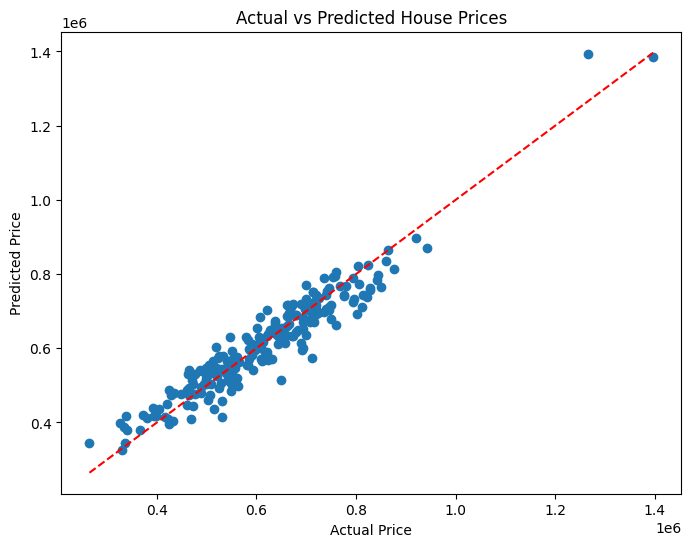

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

In [33]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

importances = pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                         Feature  Importance
0                 num__Area_SqFt    0.761588
19  cat__Property_Type_Apartment    0.048618
1                     num__Rooms    0.041280
2                num__Build_Year    0.036393
22      cat__Property_Type_Villa    0.016698
3            cat__Location_Delhi    0.012255
16     cat__Furnishing_Furnished    0.010112
4         cat__Location_Gurugram    0.007354
23              cat__Has_Pool_No    0.007175
18   cat__Furnishing_Unfurnished    0.007053


In [34]:
import joblib

joblib.dump(pipeline, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [35]:
new_house = pd.DataFrame({
    "Area_SqFt": [2200],
    "Rooms": [4],
    "Build_Year": [2015],
    "Location": ["Urban"],
    "Street_Type": ["Paved"],
    "Furnishing": ["Furnished"],
    "Property_Type": ["Villa"],
    "Has_Pool": ["Yes"]
})

prediction = pipeline.predict(new_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 670175.285
